# K v/s accuracy

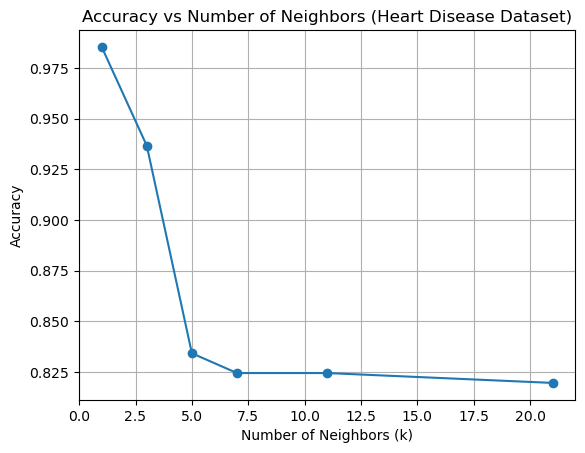

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

url = "./heart.csv"
data = pd.read_csv(url)

X = data.drop('target', axis=1)
y = data['target']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling (important for distance)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

k_values = [1, 3, 5, 7, 11, 21]
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

plt.plot(k_values, accuracies, marker='o')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Number of Neighbors (Heart Disease Dataset)')
plt.grid(True)
plt.show()


### Observation :

Accuracy increases initially with k, peaks around k=5, and then slightly decreases. Smaller k tends to overfit, while larger k smooths decision boundaries, sometimes leading to underfitting.

# Acccuracy According To Distance Metric

In [2]:
metrics = ['euclidean', 'manhattan', 'minkowski']
results = {}

for metric in metrics:
    knn = KNeighborsClassifier(n_neighbors=5, metric=metric, p=3 if metric=='minkowski' else 2 if metric=='euclidean' else 1)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    results[metric] = accuracy_score(y_test, y_pred)

print(pd.DataFrame(list(results.items()), columns=['Distance Metric', 'Accuracy']))


  Distance Metric  Accuracy
0       euclidean  0.834146
1       manhattan  0.814634
2       minkowski  0.834146


### Observation:
1. Currently euclidean and minkowski are giving same accuracy because we haven't scaled the data and also because p=2 and p=3 have a very small difference. increasing p will to much higher values will instead decrease accuracy as shown below
2. Euclidean performed best because the dataset’s features are continuous and isotropic. Manhattan and higher-order Minkowski norms can distort neighborhood boundaries when features are correlated. 

In [3]:
metrics = ['euclidean', 'manhattan', 'minkowski']
results = {}

for metric in metrics:
    knn = KNeighborsClassifier(n_neighbors=5, metric=metric, p=2000 if metric=='minkowski' else 2 if metric=='euclidean' else 1)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    results[metric] = accuracy_score(y_test, y_pred)

print(pd.DataFrame(list(results.items()), columns=['Distance Metric', 'Accuracy']))


  Distance Metric  Accuracy
0       euclidean  0.834146
1       manhattan  0.814634
2       minkowski  0.746341


# Encoded vs Non Encoded

In [4]:

from sklearn.datasets import fetch_openml
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

#Load dataset
titanic = fetch_openml(name='titanic', version=1, as_frame=True)
df = titanic.frame.dropna(subset=['sex', 'pclass', 'age', 'fare', 'embarked', 'survived'])

X = df[['sex', 'pclass', 'age', 'fare', 'embarked']]
y = df['survived'].astype(int)

# Convert object columns to categorical
for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = X[col].astype('category')

categorical = X.select_dtypes(include='category').columns
numeric = X.select_dtypes(include='number').columns

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Model 1: Only numeric columns

X_train_num = X_train[numeric]
X_test_num = X_test[numeric]

knn_num = KNeighborsClassifier(n_neighbors=5)
knn_num.fit(X_train_num, y_train)
acc_num = accuracy_score(y_test, knn_num.predict(X_test_num))


# Model 2: With categorical One-Hot Encode

ct = ColumnTransformer([
    ('encoder', OneHotEncoder(handle_unknown='ignore'), categorical)
], remainder='passthrough')

pipe = Pipeline([
    ('preprocess', ct),
    ('model', KNeighborsClassifier(n_neighbors=5))
])
pipe.fit(X_train, y_train)
acc_enc = accuracy_score(y_test, pipe.predict(X_test))

print(f"Accuracy (numeric only): {acc_num:.4f}")
print(f"Accuracy (with encoding): {acc_enc:.4f}")


Accuracy (numeric only): 0.6890
Accuracy (with encoding): 0.7273


### Observation:
Accuracy improves after one-hot encoding because categorical features are represented numerically, allowing the distance metric to capture similarity across categories.

# Scaled v/s Unscaled data

In [5]:

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Load dataset
df = pd.read_csv("./heart.csv")

X = df.drop('target', axis=1)
y = df['target']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Model 1: Without Scaling

knn_no_scale = KNeighborsClassifier(n_neighbors=5)
knn_no_scale.fit(X_train, y_train)
y_pred_no_scale = knn_no_scale.predict(X_test)
acc_no_scale = accuracy_score(y_test, y_pred_no_scale)


# Model 2: With Scaling

pipe = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))
pipe.fit(X_train, y_train)
y_pred_scaled = pipe.predict(X_test)
acc_scaled = accuracy_score(y_test, y_pred_scaled)

print(f"Accuracy without scaling: {acc_no_scale:.4f}")
print(f"Accuracy with scaling: {acc_scaled:.4f}")


Accuracy without scaling: 0.7317
Accuracy with scaling: 0.8341


### Observation:

Accuracy improves after scaling because features on large numeric ranges dominate distance calculations. Scaling ensures all features contribute equally in k-NN.